In [1]:
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, make_scorer
from datasets import Dataset, DatasetDict, load_dataset

# NOTA:

> Les dejo la explicacion y codigo, para que entiendan. Pero a la hora de subirlo, todo el marckdown deberiamos sacarlo y ahi si poner la explicacion del tp.

## Cargar desde la libreria dataset:
Si lo cargamos por separado y por un link, osea un JSON plano, Hugging Face puede interpretar el archivo como una única fila gigante debido a la estructura raíz {"data": [...]} típica del formato SQuAD.

Por eso cargamos desde la librería datasets que ya tiene el loader oficial de SQAC ya integrado.

In [3]:
# Carga directa del corpus oficial en español
raw_dataset = load_dataset("PlanTL-GOB-ES/sqac")
print(raw_dataset)

DatasetDict({
    train: Dataset({
        features: ['data'],
        num_rows: 1
    })
    validation: Dataset({
        features: ['data'],
        num_rows: 1
    })
    test: Dataset({
        features: ['data'],
        num_rows: 1
    })
})


Esto te va a devolver un objeto con las particiones por defecto (train y test o dev) y cada fila tendrá la siguiente estructura:

- id: Identificador único de la pregunta.

- title: Título o tema del artículo de Wikipedia del que proviene.

- context: El párrafo de texto completo.

- question: La pregunta formulada.

- answers: Un diccionario con text (la respuesta exacta) y answer_start (el índice del carácter donde arranca la respuesta dentro del contexto).

Las dos formas de encarar SQAC

- Opción A: Clasificación de oraciones (Answer Sentence Selection)

  Consiste en tomar el párrafo completo (context), separarlo en oraciones individuales y cruzarlas contra la pregunta (question).

  - La tarea: El modelo recibe [Pregunta + Oración] y predice una variable binaria: 1 si esa oración contiene la respuesta correcta o 0 si es una oración irrelevante.
  - A favor: Mantiene intacto el propósito real de un dataset de Question Answering (encontrar dónde está la respuesta dentro de un texto grande) y utiliza todas las columnas disponibles (question, context, answers).
  - En contra: Es más pesada computacionalmente. Al dividir un párrafo de 8 oraciones, 7 tendrán etiqueta 0 y solo 1 tendrá etiqueta 1, lo que te obliga a lidiar desde el día 1 con un desbalance de clases severo (85% ceros contra 15% unos).
- Opción B: Clasificación por tipo de pregunta (Question Classification)

  Consiste en categorizar qué información busca la pregunta (por ejemplo: Persona para "¿Quién...?", Fecha/Tiempo para "¿Cuándo...?", Lugar para "¿Dónde...?", Causa para "¿Por qué...?", o Entidad/Objeto para "¿Qué/Cuál...?").
  - La tarea: El modelo recibe únicamente el texto de la question y debe clasificarla en una de 5 o 6 clases multiclase.
  - A favor: Es un problema clásico, limpio y directo de Procesamiento de Lenguaje Natural (NLP). Encaja de forma directa con lo que pide el documento del TP para datasets de texto:
    - Etapa 1: TF-IDF + Regresión Logística multiclase.  
    - Etapa 2: Red multicapa MLP.  
    - Etapa 3.B: Embeddings de palabras (Word2Vec / FastText en español) + Red densa.  
  - En contra: SQAC no trae esa etiqueta hecha de fábrica. Si abrís el dataset, vas a ver que no existe una columna tipo_pregunta. Para usar esta opción, primero tendrías que fabricar esa etiqueta mediante código (usando expresiones regulares o reglas sobre las palabras interrogativas del español). Además, estarías descartando el 90% del dataset: ignorarías los contextos (context) y las respuestas (answers), usando solo las preguntas cortas.

## Comparativa metodológica frente a la cátedraCriterio



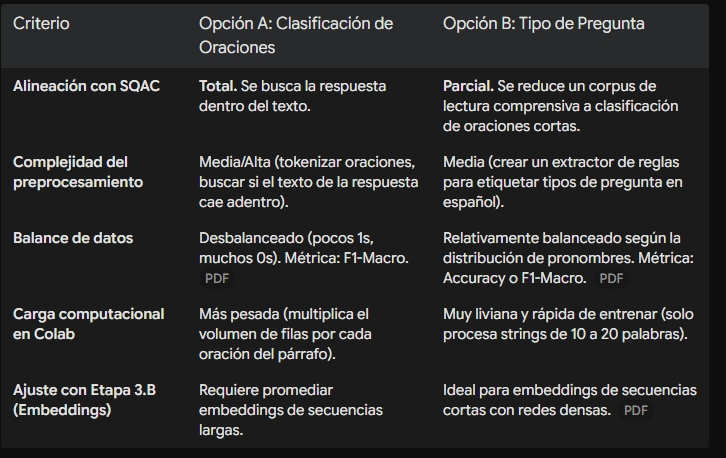

## Evaluación práctica

Si querés respetar la naturaleza técnica por la cual el docente eligió SQAC (que es el hermano en español de SQuAD, listado explícitamente en la sección 7.2 de las pautas), **la Opción A (Clasificación de oraciones)** es la más rigurosa académicamente. Demuestra que entendiste el problema de Question Answering y cómo llevarlo a Machine Learning clásico sin quemar etapas.  

Sin embargo, si tu prioridad es evitar dolores de cabeza con el tamaño de los textos, la memoria de Colab y el desbalance extremo de clases, **la Opción B (Tipo de pregunta)** simplifica drásticamente el flujo de trabajo, siempre y cuando justifiques en el Markdown de la Etapa 1 que realizaste una ingeniería de etiquetas (pseudo-labeling) para transformar el corpus en una tarea de clasificación de texto.  

## Lo que la IA elige:

Yo elegiría sin dudar la Opción A (Clasificación de oraciones), pero aplicando un truco técnico estándar en NLP: un submuestreo de oraciones negativas (negative downsampling) para eliminar de raíz el problema del desbalance y la sobrecarga de memoria.

Las razones para descartar la Opción B y quedarse con la A son tanto académicas como metodológicas:

1. El riesgo académico frente al docente
En las pautas del trabajo práctico, en la sección 7.2 de recursos recomendados, el profesor cita textualmente: "Hugging Face datasets para carga de AG News y SQUAD". En esa lista, AG News es el dataset pensado para clasificación clásica de texto corto, mientras que SQuAD / SQAC fue asignado específicamente como el desafío de comprensión lectora y Question Answering.
Si presentás un trabajo sobre SQAC donde descartás los párrafos de contexto, ignorás las respuestas reales y te inventás con expresiones regulares etiquetas artificiales para la pregunta, el docente va a notar de inmediato que esquivaste la naturaleza del dataset asignado. En la justificación de diseño de la Etapa 1 te exponés a una penalización fuerte de entrada.

2. La trampa metodológica de la Opción B
Si usás reglas heurísticas (regex) para inventar las clases (por ejemplo: si empieza con "¿Quién?" es clase Persona; si empieza con "¿Cuándo?" es clase Fecha), el modelo no está aprendiendo a entender preguntas: solo está aprendiendo a replicar una función if/else que programaste vos a mano. No hay valor analítico en entrenar una red neuronal densa de 3 capas para clasificar algo que un script de 5 líneas de Python resuelve sin margen de error.

3. Cómo hacer que la Opción A sea simple y eficiente
El único punto en contra de la Opción A era que al dividir un contexto en 8 oraciones tenías una oración positiva (etiqueta 1) y 7 negativas (etiqueta 0), lo que inflaba el tamaño del dataset y desbalanceaba las clases. Esto se resuelve de forma estándar:

- Por cada pregunta, tomás la oración que sí contiene la respuesta (clase 1).

- De las oraciones restantes del mismo párrafo que no la contienen, seleccionás al azar solo 2 oraciones negativas (clase 0).

- Descartás el resto de ese párrafo.

Con esa estrategia balanceás la proporción a una relación cómoda de $1:2$ o $1:3$, reducís drásticamente la cantidad de filas a procesar en Colab y mantenés intacto el desafío del dataset: enseñarle al modelo a identificar qué fragmento de texto responde a una duda puntual.

4. Compatibilidad con las etapas futuras

- Etapa 1: Entrenás una LogisticRegression sobre la representación TF-IDF de la dupla pregunta + " " + oracion_candidata.  
- Etapa 2: Diseñás el MLP de 3 capas ocultas usando esa misma entrada vectorial, agregándole Dropout y Early Stopping.  
- Etapa 3.B: Promediás los vectores de palabras (Word2Vec/FastText en español) de la pregunta y de la oración, los concatenás en un único vector denso y se lo pasás a la red profunda.  

El **negative downsampling** (o submuestreo de negativos) es una técnica de preprocesamiento que consiste en descartar intencionalmente una parte de los ejemplos negativos (clase 0) para evitar que superen de forma aplastante a los ejemplos positivos (clase 1).

En problemas de búsqueda de respuestas (Question Answering), sistemas de recomendación o motores de búsqueda, lo que buscás es "una aguja en un pajar". Por cada dato que te interesa (la aguja), el mundo real te arroja cientos o miles de datos irrelevantes (la paja).

El problema concreto con el dataset SQACImaginá un párrafo de tu dataset que tiene 10 oraciones y una pregunta:

> Pregunta: "¿En qué año se fundó la universidad?"

> Párrafo: Contiene 10 oraciones que hablan de la historia, la arquitectura, los rectores y las carreras.

> Oración 4: "La universidad se fundó en 1970 tras una ley nacional." $\rightarrow$ Aquí está la respuesta (Clase 1 / Positivo).

> Las otras 9 oraciones: Hablan de otras cosas $\rightarrow$ No tienen la respuesta (Clase 0 / Negativos).

Si armás todas las combinaciones posibles sin filtrar nada:

- Obtenés 1 ejemplo positivo (Pregunta + Oración 4).
- Obtenés 9 ejemplos negativos (Pregunta + Oración 1, Pregunta + Oración 2, ..., Pregunta + Oración 10).

Si tu dataset original tiene 10.000 párrafos, terminás con:
- 10.000 ejemplos positivos (10%).
- 90.000 ejemplos negativos (90%).
- Total: 100.000 filas de texto para procesar en memoria.

Qué consecuencias negativas tiene no aplicar esta técnica

- La trampa del modelo "haragán": Si el 90% de los datos son ceros, el modelo puede aprender la regla facilista de responder siempre "No contiene la respuesta" (0). Matemáticamente tendrá un 90% de Accuracy, pero el sistema será completamente inútil porque jamás encontrará una respuesta real.

- Colapso de memoria en Google Colab: Entrenar TF-IDF o redes neuronales sobre 100.000 oraciones largas consume una cantidad innecesaria de RAM y multiplica por diez el tiempo que tarda cada época de entrenamiento.

- Mucho ruido, poca señal: De esas 9 oraciones negativas, la gran mayoría son obvias e irrelevantes (por ejemplo, oraciones que hablan del clima del lugar); procesarlas una y otra vez durante el entrenamiento no le enseña nada nuevo a la red.

## Cómo funciona el Negative Downsampling paso a paso

La estrategia consiste en quedarte con todos los ejemplos valiosos (positivos) y tomar solo una muestra pequeña al azar de los negativos:


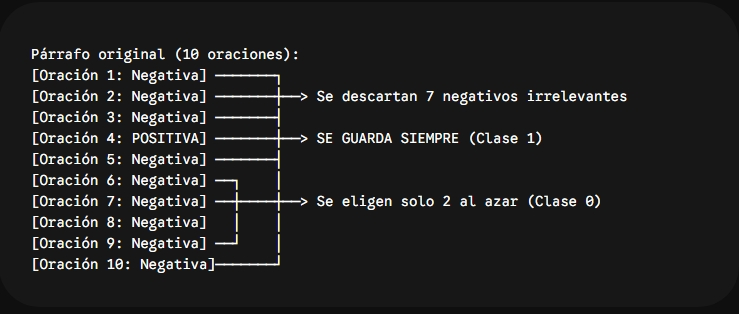

Si definís una proporción de $1:2$ (por cada oración positiva, te quedás con 2 oraciones negativas del mismo párrafo elegidas aleatoriamente):

- Tu dataset pasa de tener 100.000 filas a 30.000 filas (10.000 positivas y 20.000 negativas).
- La distribución pasa de un desbalance destructivo de 90%-10% a una relación mucho más manejable de 66% ceros y 33% unos.

- El modelo se ve obligado a aprender qué palabras y patrones diferencian a una oración relevante de una irrelevante, sin la tentación de predecir siempre cero.

# OPCION A:

# Trabajo Práctico Final: Inteligencia Artificial 2026
## Etapa 1: Análisis Exploratorio (EDA), Partición y Modelo Baseline

**Docente:** Pablo Moreira  
**Dataset Asignado:** SQAC (Spanish Question Answering Corpus)

**Grupo Nombres**:


## 1.1 Introducción y Formulación del Problema

El corpus **SQAC (Spanish Question Answering Corpus)** fue diseñado originalmente para comprensión lectora extractiva (identificar el fragmento exacto donde se ubica una respuesta dentro de un párrafo).

Para construir un sistema progresivo desde Machine Learning clásico hasta Deep Learning, reformulamos el problema como una tarea de **Selección de Oraciones Candidatas (Answer Sentence Selection)**:
1. Cada párrafo (`context`) se segmenta en oraciones individuales.
2. Cada oración se aparea con la pregunta (`question`) correspondiente.
3. Se define una variable objetivo binaria (`label`):
   * **Clase 1 (Relevante):** La oración contiene la respuesta textual esperada.
   * **Clase 0 (Irrelevante):** La oración no contiene la respuesta.

### Tratamiento de Columnas del Dataset:
* **`id`:** Se descarta por ser un identificador administrativo sin valor predictivo.
* **`title`:** Se preserva únicamente para documentar la procedencia de los artículos de Wikipedia.
* **`context` y `question`:** Constituyen la fuente textual principal que se segmentará y combinará.
* **`answers['text']`:** Se utiliza exclusivamente como referencia para asignar la etiqueta (`0` o `1`).
* **`answers['answer_start']`:** No se introduce al modelo en esta etapa, dado que evaluamos relevancia a nivel de oración completa y no localización de caracteres.

# Librerías y Carga del Dataset Oficial

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Carga del dataset SQAC oficial en español
print("Descargando SQAC desde Hugging Face...")
raw_dataset = load_dataset("PlanTL-GOB-ES/sqac")
print(raw_dataset)

Descargando SQAC desde Hugging Face...
DatasetDict({
    train: Dataset({
        features: ['data'],
        num_rows: 1
    })
    validation: Dataset({
        features: ['data'],
        num_rows: 1
    })
    test: Dataset({
        features: ['data'],
        num_rows: 1
    })
})


### 1.1.1 Descripción de Variables del Dataset Crudo

Analizamos la estructura de los datos que se compone el SQAC. Se componen de los siguiente campos:

| Variable | Tipo de Dato (Python) | Descripción |
| :--- | :--- | :--- |
| **`id`** | `str` | Identificador único alfanumérico de la pregunta. |
| **`title`** | `str` | Título o tema del artículo de Wikipedia de donde proviene el texto. |
| **`context`** | `str` | Párrafo de texto completo que sirve como contexto. |
| **`question`** | `str` | La pregunta formulada en lenguaje natural. |
| **`answers`** | `dict` | Diccionario que anida la respuesta real y su posición. |
| **`text`** (dentro de answers) | `list[str]` | Una lista que contiene el string de la respuesta exacta extraída del contexto. |
| **`answer_start`** (dentro de answers)| `list[int]` | Una lista con el índice numérico del carácter donde arranca la respuesta. |

**A continuación, se mostrará en una celda los tipos de datos y se comprobarán la existencia de los valores nulos.**

## Inspección y Extracción de Datos Crudos

In [4]:
registros_crudos = []

# Iteramos sobre la estructura anidada original del dataset de Hugging Face
for entry_wrapper in raw_dataset['train']:
    for doc in entry_wrapper['data']:
        titulo = doc.get('title', '')
        for para in doc['paragraphs']:
            contexto = para['context']
            for qa in para['qas']:
                # Extraemos de forma segura los valores dentro del diccionario 'answers'
                ans_text = qa['answers'][0]['text'] if qa.get('answers') and len(qa['answers']) > 0 else None
                ans_start = qa['answers'][0]['answer_start'] if qa.get('answers') and len(qa['answers']) > 0 else None

                registros_crudos.append({
                    'id': qa['id'],
                    'title': titulo,
                    'context': contexto,
                    'question': qa['question'],
                    'text': ans_text,
                    'answer_start': ans_start
                })

# Convertimos a DataFrame para el diagnóstico
df_crudo = pd.DataFrame(registros_crudos)

print("--- Tipos de Datos Reales (Dataset Crudo) ---")
df_crudo.info()

print("\\n--- Conteo de Valores Nulos (Dataset Crudo) ---")
print(df_crudo.isnull().sum())

--- Tipos de Datos Reales (Dataset Crudo) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15036 entries, 0 to 15035
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            15036 non-null  object
 1   title         15036 non-null  object
 2   context       15036 non-null  object
 3   question      15036 non-null  object
 4   text          15036 non-null  object
 5   answer_start  15036 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 704.9+ KB
\n--- Conteo de Valores Nulos (Dataset Crudo) ---
id              0
title           0
context         0
question        0
text            0
answer_start    0
dtype: int64


Al realizar el analisis comprobamos que (en el data set crudo) no existen valores nulos, esto se debe a que la base de datos SQAC esta estructurado de tal forma para el entrenamiento de algoritmos, es decir,ya viene limpia para que a ningún ejemplo le falte la información necesaria (contexto, pregunta y respuesta) para que el modelo pueda aprender correctamente.

## 1.2 Estrategia y Justificación de la Partición (Train, Dev y Test)

Para este trabajo práctico adoptamos la **partición oficial provista por los creadores de SQAC** (`train`, `validation` como Dev, y `test`):

### ¿Por qué usar la división oficial del dataset? (Justificación metodológica):
1. **Prevención de Fuga de Datos (*Data Leakage*):** Si tomáramos solo `train.json` y le aplicáramos un `train_test_split` aleatorio, una pregunta sobre un artículo de Wikipedia podría quedar en Train y otra pregunta sobre el mismo texto podría quedar en Dev o Test. El modelo no aprendería a razonar lectura comprensiva; memorizaría términos del artículo específico. Al usar los archivos oficiales, garantizamos que Dev y Test midan la capacidad real del modelo de responder sobre textos de temas nunca vistos.

2. **Blindaje del Conjunto Test:** El conjunto `Test` se procesa y reserva **bajo llave**. No se utiliza para ajustar vocabulario, ni para seleccionar modelos, ni para calibrar hiperparámetros. Se evaluará por única vez en la **Etapa 5** para constatar que no hubo sobreajuste al conjunto Dev.

> Todas las decisiones intermedias se medirán exclusivamente sobre `Dev`.

## 1.3 Extracción de Pares Pregunta-Oración

Transformamos las muestras crudas descomponiendo los párrafos en oraciones y contrastándolas contra la respuesta verdadera, **sin aplicar ningún submuestreo previo (*negative downsampling*)**, a fin de observar y diagnosticar empíricamente la naturaleza estadística real del corpus.

A continuación, aplicamos este procedimiento a los tres conjuntos (`Train`, `Dev` y `Test`):

In [6]:
def segmentar_oraciones(texto):
    """Divide un texto en oraciones utilizando separadores de puntuación comunes."""
    oraciones = re.split(r'(?<=[.?!])\s+', texto.strip())
    return [o.strip() for o in oraciones if len(o.strip()) > 3]

def construir_pares_desde_split(dataset_split, max_docs=None):
    """
    Recorre los documentos de un split y arma el DataFrame de pares (Pregunta, Oración).
    """
    registros = []

    for entry_wrapper in dataset_split:
        docs = entry_wrapper['data']
        if max_docs is not None:
            docs = docs[:max_docs]

        for doc in docs:
            for para in doc['paragraphs']:
                contexto = para['context']
                oraciones = segmentar_oraciones(contexto)
                num_oraciones = len(oraciones)

                for qa in para['qas']:
                    pregunta = qa["question"]
                    respuestas_list = qa.get("answers", [])

                    if not respuestas_list:
                        continue
                    respuesta_real = respuestas_list[0]["text"].strip().lower()

                    for oracion in oraciones:
                        es_positiva = 1 if (respuesta_real != "" and respuesta_real in oracion.lower()) else 0
                        registros.append({
                            "pregunta": pregunta,
                            "oracion": oracion,
                            "texto_combinado": f"{pregunta} [SEP] {oracion}",
                            "label": es_positiva,
                            "len_pregunta": len(pregunta.split()),
                            "len_oracion": len(oracion.split()),
                            "num_oraciones_contexto": num_oraciones
                        })
    return pd.DataFrame(registros)

print("Procesando pares de Train...")
df_pares = construir_pares_desde_split(raw_dataset["train"])

print("Procesando pares de Dev (Validation)...")
df_pares_dev = construir_pares_desde_split(raw_dataset["validation"])

print("Procesando pares de Test (Blindado)...")
df_pares_test = construir_pares_desde_split(raw_dataset["test"])

# Verificación de proporcionalidad de clases en los tres conjuntos (Pauta 4.1.2)
tabla_proporciones = pd.DataFrame({
    "Conjunto": ["Train", "Dev (Validation)", "Test"],
    "Total Muestras": [len(df_pares), len(df_pares_dev), len(df_pares_test)],
    "Positivos (1)": [df_pares["label"].sum(), df_pares_dev["label"].sum(), df_pares_test["label"].sum()],
    "% Positivos (1)": [f"{df_pares['label'].mean():.2%}", f"{df_pares_dev['label'].mean():.2%}", f"{df_pares_test['label'].mean():.2%}"],
    "% Negativos (0)": [f"{(1 - df_pares['label'].mean()):.2%}", f"{(1 - df_pares_dev['label'].mean()):.2%}", f"{(1 - df_pares_test['label'].mean()):.2%}"]
})

print("\n--- Verificación de Proporcionalidad entre Conjuntos (Pauta 4.1.2) ---")
display(tabla_proporciones)
df_pares.head(3)

Procesando pares de Train...
Procesando pares de Dev (Validation)...
Procesando pares de Test (Blindado)...

--- Verificación de Proporcionalidad entre Conjuntos (Pauta 4.1.2) ---


,Conjunto,Total Muestras,Positivos (1),% Positivos (1),% Negativos (0)
0,Train,117443,17449,14.86%,85.14%
1,Dev (Validation),15323,2271,14.82%,85.18%
2,Test,13559,2193,16.17%,83.83%


,pregunta,oracion,texto_combinado,label,len_pregunta,len_oracion,num_oraciones_contexto
0,¿Qué influencia convirtió Japón en una nación ...,"La historia de Japón (日本の歴史 o 日本史, Nihon no re...",¿Qué influencia convirtió Japón en una nación ...,0,8,22,4
1,¿Qué influencia convirtió Japón en una nación ...,Algunos de estos hechos aparecen aislados e in...,¿Qué influencia convirtió Japón en una nación ...,0,8,47,4
2,¿Qué influencia convirtió Japón en una nación ...,"Asimismo, otra de las influencias foráneas fue...",¿Qué influencia convirtió Japón en una nación ...,1,8,36,4


## 1.3.1 Diagnóstico de Data Mismatch Potencial
En el caso de SQAC, el riesgo es evidente:

Los datos vienen de artículos de Wikipedia en español. Son textos académicos, enciclopédicos, con vocabulario formal y preguntas redactadas por lingüistas que sabían de antemano que la respuesta estaba en el párrafo.

Pero en el mundo real los usuarios cuando hacen preguntas, suelen usar lenguaje coloquial, modismos, faltas de ortografia, abreviaciones o preguntas ambiguas sin contexto claro.

Entonces podemos ver de antemano que hay un riesgo severo de Data Mismatch

El modelo calibrado con exito podria ver su desempeño afectado drastricamente si se lanza a usuarios reales, por la diferencia entre los datos de laboratorio y el lenguaje cotidiano en produccion.

### 1.3.2 Descripción Estadística y Valores Nulos

Antes de generar las visualizaciones, realizamos una inspección matemática de las variables para cumplir con la primera fase del análisis exploratorio:

* **Tipos de datos:** Verificamos la estructura general del dataset, confirmando que los textos se procesen como *strings* y las métricas de longitud como enteros.
* **Valores nulos:** Comprobamos la integridad de los datos garantizando que no existan campos vacíos que puedan generar errores durante el entrenamiento.
* **Rangos numéricos:** Calculamos la estadística descriptiva (promedio, mínimos, máximos y cuartiles) de las longitudes de los textos.

**A continuación, se mostrará en una celda los tipos de datos y se comprobarán la existencia de los valores nulos.**

In [7]:
print("--- Información general y Tipos de Datos ---")
df_pares.info()

print("\n--- Conteo de Valores Nulos ---")
print(df_pares.isnull().sum())

print("\n--- Estadísticas Descriptivas (Rangos) ---")
display(df_pares[['len_oracion', 'len_pregunta', 'num_oraciones_contexto']].describe())

--- Información general y Tipos de Datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117443 entries, 0 to 117442
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   pregunta                117443 non-null  object
 1   oracion                 117443 non-null  object
 2   texto_combinado         117443 non-null  object
 3   label                   117443 non-null  int64 
 4   len_pregunta            117443 non-null  int64 
 5   len_oracion             117443 non-null  int64 
 6   num_oraciones_contexto  117443 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 6.3+ MB

--- Conteo de Valores Nulos ---
pregunta                  0
oracion                   0
texto_combinado           0
label                     0
len_pregunta              0
len_oracion               0
num_oraciones_contexto    0
dtype: int64

--- Estadísticas Descriptivas (Rangos) ---


,len_oracion,len_pregunta,num_oraciones_contexto
count,117443.000000,117443.000000,117443.000000
mean,28.211073,8.521904,13.106401
std,15.385191,3.245891,17.499797
min,1.000000,2.000000,1.000000
25%,17.000000,6.000000,6.000000
50%,26.000000,8.000000,9.000000
75%,37.000000,10.000000,14.000000
max,257.000000,31.000000,207.000000


Al realizar el analisis cde nuevo en Train ya en pares. No existen valores nulos.

## 1.4 Análisis Exploratorio de Datos (EDA)

Se generan tres visualizaciones para diagnosticar:
1. La proporción entre oraciones relevantes (clase 1) e irrelevantes (clase 0).
2. La distribución de longitud de las oraciones candidatas y las preguntas.
3. La densidad de oraciones por párrafo en el dataset.

/tmp/ipykernel_607/375073274.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_pares, x="label", ax=axes[0], palette=["#e74c3c", "#2ecc71"])


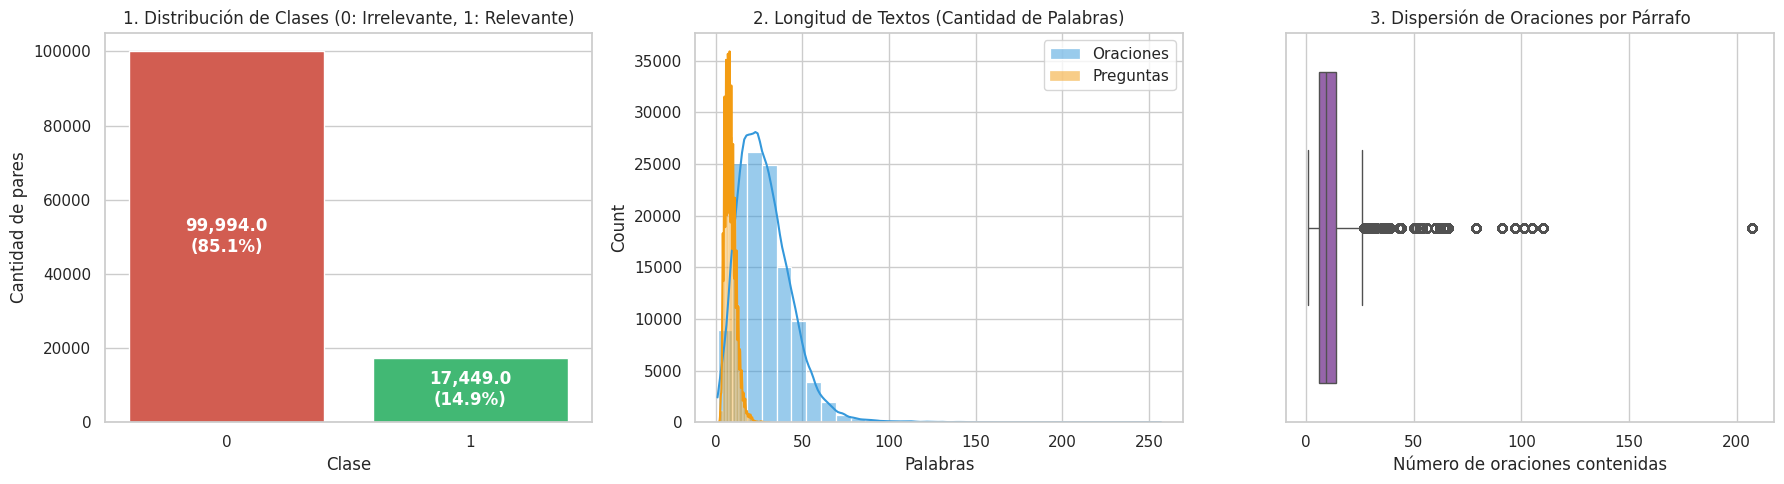

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Desbalance de Clases (Descubrimiento empírico)
sns.countplot(data=df_pares, x="label", ax=axes[0], palette=["#e74c3c", "#2ecc71"])
axes[0].set_title("1. Distribución de Clases (0: Irrelevante, 1: Relevante)")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Cantidad de pares")
for p in axes[0].patches:
    total = len(df_pares)
    porcentaje = f"{100 * p.get_height() / total:.1f}%"
    axes[0].annotate(f"{p.get_height():,}\n({porcentaje})",
                     (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha="center", va="center", color="white", fontweight="bold")

# Gráfico 2: Longitud de oraciones vs. preguntas (en palabras)
sns.histplot(df_pares["len_oracion"], bins=30, ax=axes[1], color="#3498db", kde=True, label="Oraciones")
sns.histplot(df_pares["len_pregunta"], bins=15, ax=axes[1], color="#f39c12", kde=True, label="Preguntas")
axes[1].set_title("2. Longitud de Textos (Cantidad de Palabras)")
axes[1].set_xlabel("Palabras")
axes[1].legend()

# Gráfico 3: Cantidad de oraciones por contexto
sns.boxplot(x=df_pares["num_oraciones_contexto"], ax=axes[2], color="#9b59b6")
axes[2].set_title("3. Dispersión de Oraciones por Párrafo")
axes[2].set_xlabel("Número de oraciones contenidas")

plt.tight_layout()
plt.show()

## 1.5 Interpretación de Hallazgos y Justificación de la Métrica Única

### 1. El Desbalance de Clases y la Invalidez de Accuracy:
El Gráfico 1 demuestra empíricamente que alrededor del **85.1% de las oraciones corresponden a la clase 0 (irrelevante)**, mientras que solo un **14.9% contiene la respuesta buscada (clase 1)**.
* Si utilizáramos **Accuracy**, un modelo trivial que prediga siempre `0` parecería "bueno", pero sería completamente inútil porque jamás encontraría una respuesta real.
* **Métrica de Número Único Elegida:** Definimos **F1-Score Macro** como métrica rectora. Al calcular la media armónica de precisión y recall de ambas clases por separado y promediarlas, castiga severamente al modelo si este decide ignorar a la clase minoritaria.

### 2. Diagnóstico de Longitudes:

- **Eje X** (Palabras): Longitud del texto medida en cantidad de palabras separadas por espacios.

- **Eje Y** (Count): Cantidad de muestras (frecuencia absoluta) que tienen exactamente esa longitud.


#### La curva naranja (Preguntas):

Comportamiento:

Sube de manera vertical hasta un pico muy alto de más de 35.000 preguntas que tienen entre (alrededor) de 7 a 9 palabras. Cae abruptamente antes de llegar a las 20-25 palabras.

Interpretación:

Las preguntas en español son directas y homogéneas. Nadie formula una pregunta enciclopédica de 50 palabras; se concentran casi todas en menos de 15 palabras.

#### La curva y barras azules (Oraciones):

Comportamiento:

Tienen una distribución mucho más abierta, con un pico centrado entre las 20 y 35 palabras (alcanzando cerca de 27.000 oraciones). Presenta una asimetría positiva (sesgo hacia la derecha), extendiéndose con una cola larga hacia las 60, 100 palabras.

Interpretación e implicancia técnica:

El texto de Wikipedia contiene oraciones complejas y subordinadas. Esta diferencia de escala entre ambas curvas demuestra que las oraciones son las que determinan el consumo de memoria. Para las etapas de Deep Learning (Etapas 2 y 3), este gráfico justifica establecer un límite de truncamiento o secuencia máxima (por ejemplo, 128 o 256 tokens) que cubra el 95% de los datos sin desperdiciar cómputo rellenando con ceros (padding).


#### 3. Dispersión de Oraciones por Párrafo (Gráfico 3)

 **Valores Atípicos (Outliers):** El diagrama de caja (Gráfico 3) revelan una dispersión extrema en la longitud de los textos. Mientras que el 75% de los párrafos contiene 14 oraciones o menos, existen casos extremos donde un solo contexto alcanza las 207 oraciones.
Esta dispersión genera un problema práctico importante: ingresar párrafos tan extensos a un algoritmo es altamente ineficiente. Estos casos atípicos no solo corren el riesgo de saturar la memoria RAM durante el entrenamiento, sino que añaden demasiada informacion irrelevante que le dificulta a la red neuronal encontrar los patrones correctos.
Detectar esto temprano justifica nuestra próxima decisión técnica: al momento de vectorizar los textos o pasarlos a una red neuronal en las siguientes etapas, sera obligatoriamente agregar un limite para que no colapse el modelo.



## 1.6 Preprocesamiento y Entrenamiento del Modelo Baseline

### Preprocesamiento Mínimo:
1. **Encoding:** Se utiliza `TfidfVectorizer` para convertir las secuencias de texto en representaciones numéricas de 5.000 características basadas en unigramas y bigramas (`ngram_range=(1, 2)`).
2. **Normalización:** La función aplica por defecto la norma Euclidiana $L_2$ (`norm='l2'`), escalando los vectores a una magnitud unitaria para que la extensión del texto no distorsione el cálculo del gradiente.

El vectorizador ajusta su vocabulario (`fit_transform`) **únicamente con los datos de Train**, y luego transforma (`transform`) a Dev sin filtrar información. Se entrena una `LogisticRegression` con `class_weight='balanced'` para contrarrestar el desbalance diagnosticado en el EDA.

> Decisión: Gracias a class_weight='balanced', el algoritmo ajusta las funciones de costo para compensar la baja frecuencia de la clase 1. Si la probabilidad calculada supera el umbral de decisión, asigna la etiqueta 1 (oración relevante); de lo contrario, asigna 0 (irrelevante).

In [13]:
# 1. Ajuste del vectorizador solo en Train y transformación de Dev
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), norm='l2')

X_train_vec = vectorizer.fit_transform(df_pares['texto_combinado'])
y_train = df_pares['label']

X_dev_vec = vectorizer.transform(df_pares_dev['texto_combinado'])
y_dev = df_pares_dev['label']

# 2. Entrenamiento del clasificador lineal
baseline_model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=500)
baseline_model.fit(X_train_vec, y_train)

# 3. Predicciones en el conjunto de desarrollo (Dev)
y_dev_pred = baseline_model.predict(X_dev_vec)

# 4. Cálculo y fijación de la Métrica Única de Referencia (Pauta 4.1.3)
BASELINE_F1_DEV = f1_score(y_dev, y_dev_pred, average="macro")
BASELINE_ACC_DEV = accuracy_score(y_dev, y_dev_pred)

print("=" * 60)
print(f"Piso de Referencia Establecido en Dev (F1-Macro): {BASELINE_F1_DEV:.4f}")
print(f"Accuracy alcanzado en Dev:                        {BASELINE_ACC_DEV:.4f}")
print("=" * 60)

Piso de Referencia Establecido en Dev (F1-Macro): 0.5547
Accuracy alcanzado en Dev:                        0.6566


¿Por que con Dev?

La decisión de evaluar el modelo y fijar la métrica de referencia en el conjunto Dev (Development / Validación) responde a dos principios metodológicos de Machine Learning:

- **Por qué NO en Train:**
Train es el material de estudio donde el algoritmo ajusta sus parámetros ($W$ y $b$) mediante Backpropagation. Si midiéramos la métrica de referencia en Train, caeríamos en la trampa del sobreajuste (Varianza Alta): el modelo podría tener un 98% de acierto habiendo memorizado los ejemplos exactos con su ruido, pero ser incapaz de predecir nada nuevo. Necesitamos comprobar el rendimiento en datos que el modelo jamás vio durante el cálculo de gradientes.

- **Por qué SÍ en Dev:** Dev es el simulacro de examen. Proviene de la misma distribución o de una distribución de desarrollo, pero la red no aprende de él. Nos da una medida real de qué tan bien generaliza el sistema y sirve como el árbitro imparcial para comparar semana a semana: si el MLP de la Etapa 2 o los embeddings de la Etapa 3 superan el puntaje de Dev del baseline, sabemos que el modelo mejoró de verdad.



## 1.7 Evaluación del Baseline en Dev y Matriz de Confusión

A continuación, inspeccionamos el rendimiento desglosado por clase mediante el reporte de clasificación y graficamos la **matriz de confusión** para analizar la distribución entre verdaderos positivos, falsos positivos y falsos negativos.Vectorización y Entrenamiento del Baseline


Reporte de Clasificación Detallado en Dev:
                 precision    recall  f1-score   support

Irrelevante (0)       0.91      0.67      0.77     13052
  Relevante (1)       0.24      0.60      0.34      2271

       accuracy                           0.66     15323
      macro avg       0.57      0.63      0.55     15323
   weighted avg       0.81      0.66      0.70     15323



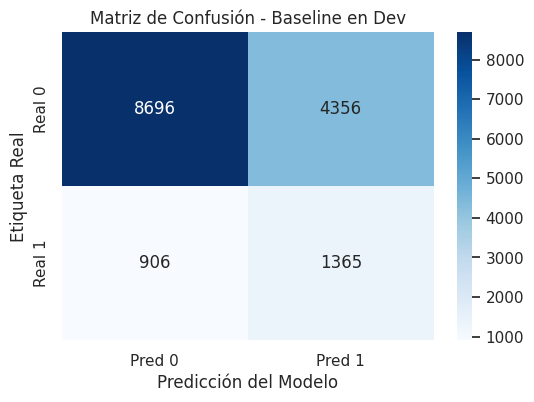

In [16]:
print("\nReporte de Clasificación Detallado en Dev:")
print(classification_report(y_dev, y_dev_pred, target_names=["Irrelevante (0)", "Relevante (1)"]))

# Matriz de Confusión
cm = confusion_matrix(y_dev, y_dev_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Real 0", "Real 1"])
plt.title("Matriz de Confusión - Baseline en Dev")
plt.ylabel("Etiqueta Real")
plt.xlabel("Predicción del Modelo")
plt.show()

## 1.8 Conclusiones y Registro de Referencia (Etapa 1)

* **Punto de Referencia Establecido:** El baseline de Regresión Logística sobre representaciones TF-IDF establece nuestro piso de rendimiento en Dev con la métrica **F1-Macro** calculada.
* **Diagnóstico Inicial:** El balanceo de pesos permitió que el modelo reconozca la clase minoritaria, pero se observa una cantidad importante de falsos positivos debido a que muchas oraciones del mismo párrafo comparten vocabulario con la pregunta sin contener la respuesta exacta.
* **Próximo Paso (Etapa 2):** Se seleccionará una muestra de **50 ejemplos mal clasificados en Dev** para categorizarlos manualmente (sesgo, varianza o ambigüedad) y se implementará una red neuronal densa (MLP de 3 capas ocultas) buscando superar este puntaje base.

## Codigo recicable

     RESULTADO DEL BASELINE EN CONJUNTO DEV
Métrica Única Principal (F1-Macro): 0.5547
Accuracy de referencia:             0.6566

Reporte de Clasificación Detallado en Dev:
                 precision    recall  f1-score   support

Irrelevante (0)       0.91      0.67      0.77     13052
  Relevante (1)       0.24      0.60      0.34      2271

       accuracy                           0.66     15323
      macro avg       0.57      0.63      0.55     15323
   weighted avg       0.81      0.66      0.70     15323



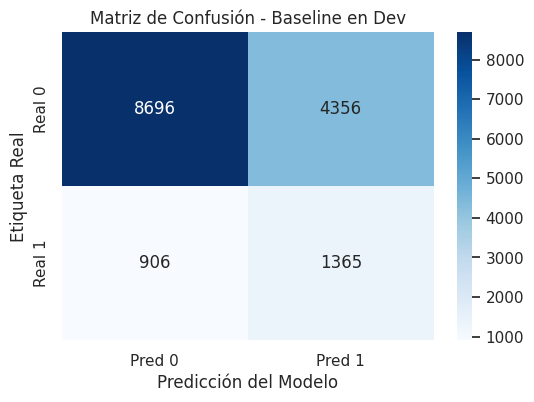

In [9]:
# 1. Ajuste del vectorizador ÚNICAMENTE sobre Train
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), norm='l2')

X_train_vec = vectorizer.fit_transform(df_pares["texto_combinado"])
y_train = df_pares["label"]

# 2. Transformación de Dev (sin tocar Test ni fugar información de vocabulario)
X_dev_vec = vectorizer.transform(df_pares_dev["texto_combinado"])
y_dev = df_pares_dev["label"]

# 3. Entrenamiento del Baseline
baseline_model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=500)
baseline_model.fit(X_train_vec, y_train)

# 4. Predicción en Dev
y_dev_pred = baseline_model.predict(X_dev_vec)

# 5. Cálculo y reporte de la métrica única
BASELINE_F1_DEV = f1_score(y_dev, y_dev_pred, average="macro")
acc_dev = accuracy_score(y_dev, y_dev_pred)

print("="*60)
print("     RESULTADO DEL BASELINE EN CONJUNTO DEV")
print("="*60)
print(f"Métrica Única Principal (F1-Macro): {BASELINE_F1_DEV:.4f}")
print(f"Accuracy de referencia:             {acc_dev:.4f}")
print("="*60)

print("\nReporte de Clasificación Detallado en Dev:")
print(classification_report(y_dev, y_dev_pred, target_names=["Irrelevante (0)", "Relevante (1)"]))

# Matriz de Confusión
cm = confusion_matrix(y_dev, y_dev_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Real 0", "Real 1"])
plt.title("Matriz de Confusión - Baseline en Dev")
plt.ylabel("Etiqueta Real")
plt.xlabel("Predicción del Modelo")
plt.show()